In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import os
from PIL import Image
from sklearn.preprocessing import LabelEncoder
import snntorch.spikeplot as splt
from IPython.display import HTML
from torchviz import make_dot

In [1]:
DATA_DIR = "../../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [9]:
train_df = pd.read_csv(f"{DATASET_DIR}/train1_multi.csv")

In [ ]:
from snntorch import spikegen

class CustomDatasetRate(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, num_steps=4, gain=1):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.num_steps = num_steps
        self.gain = gain

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            img = spikegen.rate(img, num_steps=self.num_steps, gain=self.gain)
            return img, label

class CustomDatasetLatency(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, num_steps=25, tau=1, threshold=0.01):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.num_steps = num_steps
        self.tau = tau
        self.threshold = threshold

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            img = spikegen.latency(img, num_steps=self.num_steps, tau=self.tau, threshold=self.threshold, normalize=True, linear=True, clip=True)
            return img, label
        
class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label


In [11]:
LE = LabelEncoder()
LE.fit(train_df["Label"])
train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

In [116]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=transform)
train_dataset_rate = CustomDatasetRate(train_df_encoded, f"{DATASET_DIR}/images", transform=transform, num_steps=100, gain=0.25)
train_dataset_latency = CustomDatasetLatency(train_df_encoded, f"{DATASET_DIR}/images", transform=transform, num_steps=4, tau=5, threshold=0.3)

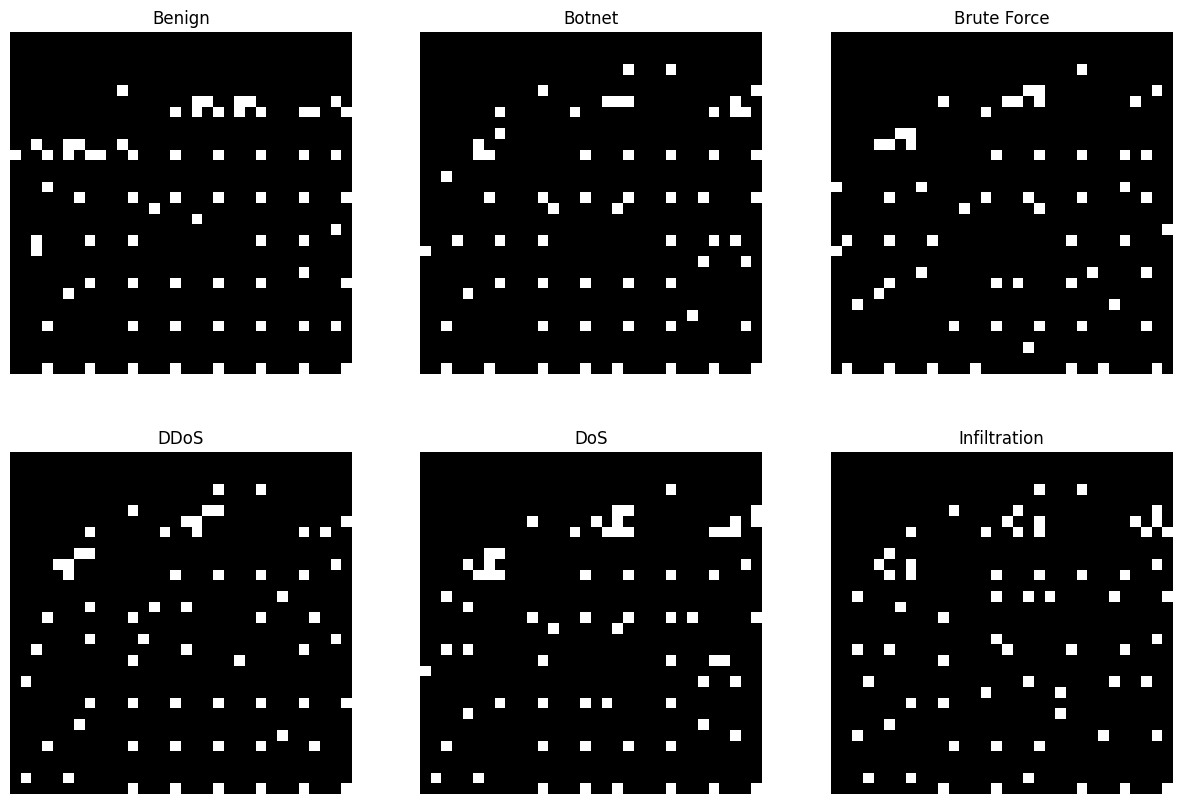

In [33]:
# plot image for each label from train_df_encoded (total labels - 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# plot from train_df_encoded
for label in range(6):
    img = train_df_encoded[train_df_encoded["Label"] == label].iloc[0]["Image"]
    img_path = os.path.join(f"{DATASET_DIR}/images", img)
    with Image.open(img_path) as img:
        axes[label//3, label%3].imshow(img, cmap="gray")
        axes[label//3, label%3].set_title(LE.inverse_transform([label])[0])
        axes[label//3, label%3].axis("off")
plt.show()


In [31]:
plt.rcParams['animation.ffmpeg_path'] = "C:/path/ffmpeg.exe"

In [117]:
rate_spike_data_sample = train_dataset_rate[0][0][:,0]
latency_spike_data_sample = train_dataset_latency[0][0][:,0]

rate_spike_data_sample.shape, latency_spike_data_sample.shape

(torch.Size([100, 32, 32]), torch.Size([4, 32, 32]))

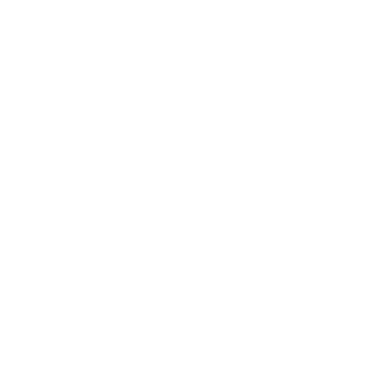

In [96]:
fig, ax = plt.subplots()
anim = splt.animator(rate_spike_data_sample, fig, ax)

HTML(anim.to_html5_video())

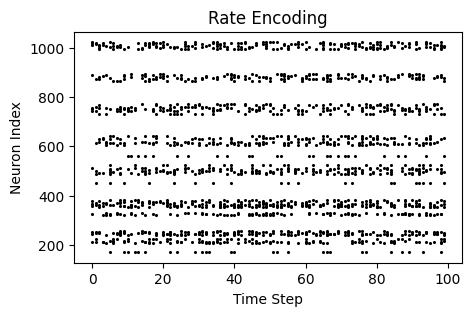

In [105]:
# reshape to a 2d tensor with num_step as first val
rate_spike_data_sample_reshaped = rate_spike_data_sample.reshape(100, -1)


fig = plt.figure(figsize=(5, 3), facecolor="w")
ax = fig.add_subplot(111)
splt.raster(rate_spike_data_sample_reshaped, ax, s=1.5, c="k")
plt.title("Rate Encoding")
plt.xlabel("Time Step")
plt.ylabel("Neuron Index")
plt.show()

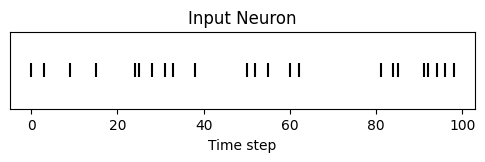

In [106]:
idx = 210  # index into 210th neuron

fig = plt.figure(facecolor="w", figsize=(6, 1))
ax = fig.add_subplot(111)

splt.raster(rate_spike_data_sample.reshape(100, -1)[:, idx].unsqueeze(1), ax, s=100, c="black", marker="|")

plt.title("Input Neuron")
plt.xlabel("Time step")
plt.yticks([])
plt.show()

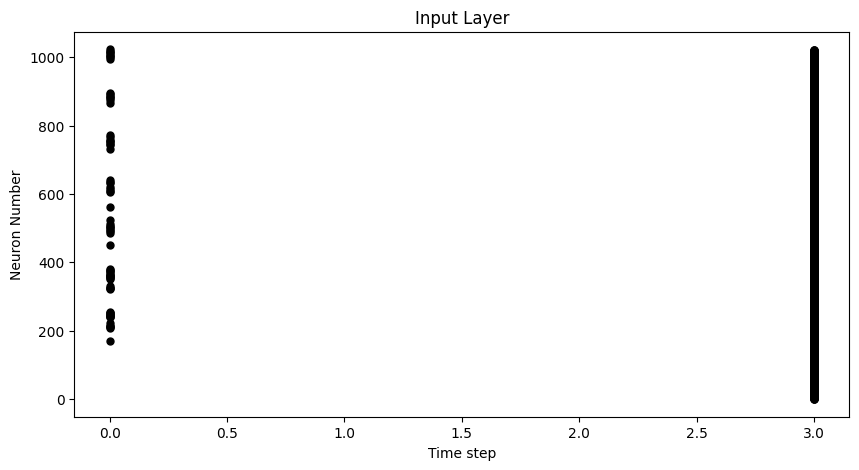

In [118]:
fig = plt.figure(facecolor="w", figsize=(10, 5))
ax = fig.add_subplot(111)
splt.raster(latency_spike_data_sample.view(4, -1), ax, s=25, c="black")

plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

In [ ]:
fig, ax = plt.subplots()
anim = splt.animator(latency_spike_data_sample, fig, ax)

HTML(anim.to_html5_video())

In [5]:
base_dir = "../../models/checkpoints"

available_dirs = {
    0 : "cnn",
    1 : "multi_cnn",
    2 : "basic_snn",
    3 : "basic_multisnn",
    4 : "paper_snn",
    5 : "paper_multisnn"
}

In [11]:
def load_metrics_from_checkpoint(path, filename, only_history=True):
    full_path = os.path.join(path, filename)
    model_dict = torch.load(full_path, weights_only=False)

    return model_dict["history"] if only_history else model_dict

In [12]:
model_metrics = load_metrics_from_checkpoint(f"{base_dir}/{available_dirs[0]}", "abstract_cnn.pt", only_history=False)

model_metrics.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'loss', 'scheduler_state_dict', 'learning_rate', 'history'])

In [14]:
model_metrics["history"].keys()

dict_keys(['overall_accuracy', 'train_loss', 'val_loss', 'benign_metrics', 'malicious_metrics'])

In [ ]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    if 'benign_metrics' in history:
        # Binary classification setup
        # Plot overall metrics
        plt.figure(figsize=(15, 10))
        plt.subplot(2, 2, 1)
        plt.plot(history['overall_accuracy']['train'], label='Train')
        plt.plot(history['overall_accuracy']['val'], label='Validation')
        plt.title('Overall Accuracy')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(2, 2, 2)
        plt.plot(history['overall_precision']['train'], label='Train')
        plt.plot(history['overall_precision']['val'], label='Validation')
        plt.title('Overall Precision')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(2, 2, 3)
        plt.plot(history['overall_recall']['train'], label='Train')
        plt.plot(history['overall_recall']['val'], label='Validation')
        plt.title('Overall Recall')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(2, 2, 4)
        plt.plot(history['overall_f1']['train'], label='Train')
        plt.plot(history['overall_f1']['val'], label='Validation')
        plt.title('Overall F1 Score')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Plot loss
        plt.figure()
        plt.plot(history['train_loss'], label='Train')
        plt.plot(history['val_loss'], label='Validation')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()
        
        # Plot benign metrics
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.plot(history['benign_metrics']['train']['precision'], label='Train')
        plt.plot(history['benign_metrics']['val']['precision'], label='Validation')
        plt.title('Benign Precision')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(1, 3, 2)
        plt.plot(history['benign_metrics']['train']['recall'], label='Train')
        plt.plot(history['benign_metrics']['val']['recall'], label='Validation')
        plt.title('Benign Recall')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(1, 3, 3)
        plt.plot(history['benign_metrics']['train']['f1'], label='Train')
        plt.plot(history['benign_metrics']['val']['f1'], label='Validation')
        plt.title('Benign F1 Score')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Plot malicious metrics
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.plot(history['malicious_metrics']['train']['precision'], label='Train')
        plt.plot(history['malicious_metrics']['val']['precision'], label='Validation')
        plt.title('Malicious Precision')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(1, 3, 2)
        plt.plot(history['malicious_metrics']['train']['recall'], label='Train')
        plt.plot(history['malicious_metrics']['val']['recall'], label='Validation')
        plt.title('Malicious Recall')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(1, 3, 3)
        plt.plot(history['malicious_metrics']['train']['f1'], label='Train')
        plt.plot(history['malicious_metrics']['val']['f1'], label='Validation')
        plt.title('Malicious F1 Score')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    else:
        # Multi-class classification setup
        # Plot metrics
        plt.figure(figsize=(15, 10))
        metrics = ['accuracy', 'precision', 'recall', 'f1']
        for i, metric in enumerate(metrics):
            plt.subplot(2, 2, i+1)
            plt.plot(history['train_metrics'][metric], label='Train')
            plt.plot(history['val_metrics'][metric], label='Validation')
            plt.title(metric.capitalize())
            plt.xlabel('Epoch')
            plt.legend()
        plt.tight_layout()
        plt.show()
        
        # Plot loss
        plt.figure()
        plt.plot(history['train_loss'], label='Train')
        plt.plot(history['val_loss'], label='Validation')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

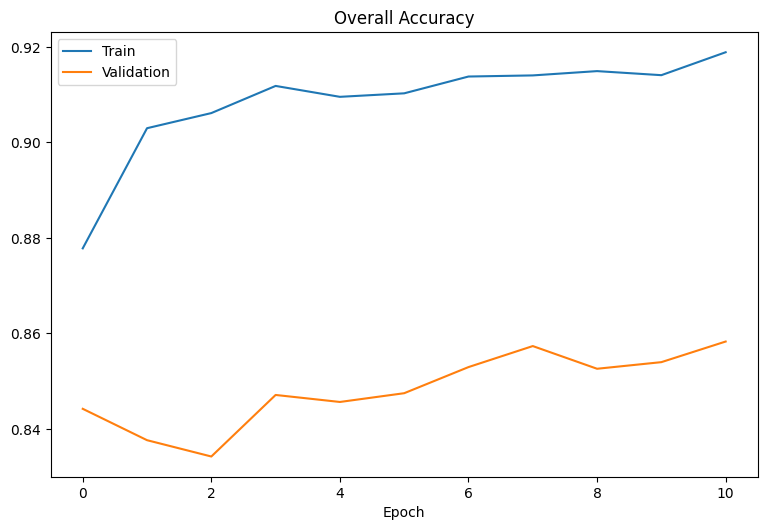

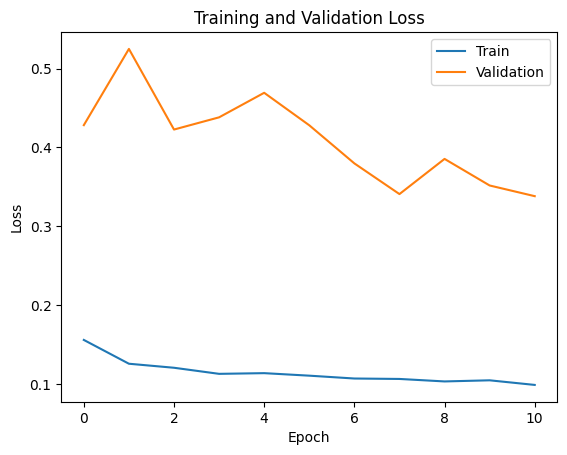

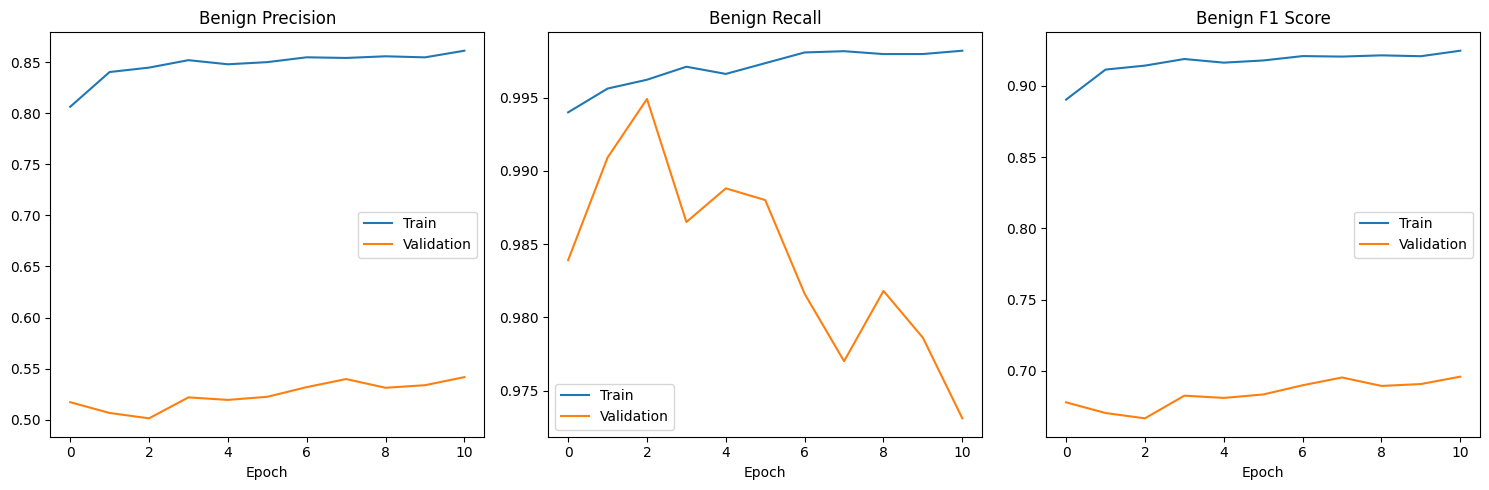

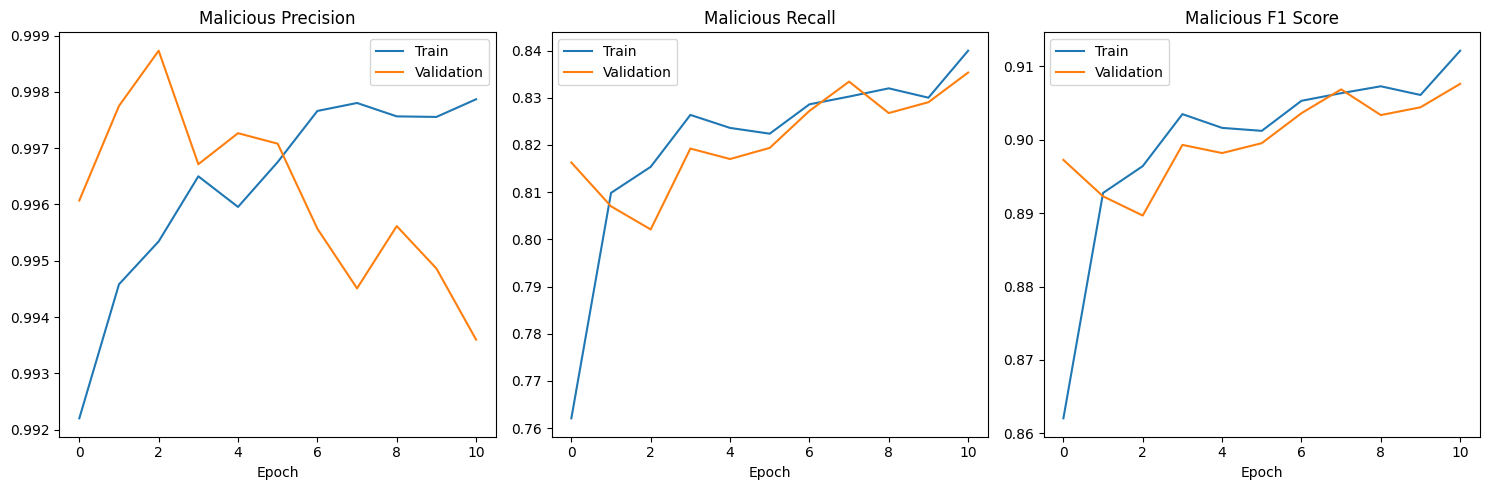

In [20]:
plot_metrics(model_metrics["history"])

In [28]:
def plot_metrics_snn(metrics):
    # Determine the format
    if 'class_metrics' in metrics['train']:
        format_type = 'format_1'
    else:
        format_type = 'format_2'
    
    # Plot training and validation metrics
    plt.figure(figsize=(15, 10))
    
    # Plot loss and average loss
    plt.subplot(2, 2, 1)
    plt.plot(metrics['train']['loss'], label='Train Loss')
    plt.plot(metrics['val']['loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(2, 2, 2)
    plt.plot(metrics['train']['avg_loss'], label='Train Avg Loss')
    plt.plot(metrics['val']['avg_loss'], label='Validation Avg Loss')
    plt.title('Average Loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    # Plot accuracy and F1 score
    plt.subplot(2, 2, 3)
    plt.plot(metrics['train']['acc'], label='Train Accuracy')
    plt.plot(metrics['val']['acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(2, 2, 4)
    plt.plot(metrics['train']['f1'], label='Train F1 Score')
    plt.plot(metrics['val']['f1'], label='Validation F1 Score')
    plt.title('F1 Score')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Plot class-specific metrics for format_1
    if format_type == 'format_1':
        plt.figure(figsize=(15, 10))
        
        # Benign metrics
        plt.subplot(2, 3, 1)
        plt.plot([x['benign']['precision'] for x in metrics['train']['class_metrics']], label='Train Benign Precision')
        plt.plot([x['benign']['precision'] for x in metrics['val']['class_metrics']], label='Validation Benign Precision')
        plt.title('Benign Precision')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(2, 3, 2)
        plt.plot([x['benign']['recall'] for x in metrics['train']['class_metrics']], label='Train Benign Recall')
        plt.plot([x['benign']['recall'] for x in metrics['val']['class_metrics']], label='Validation Benign Recall')
        plt.title('Benign Recall')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(2, 3, 3)
        plt.plot([x['benign']['f1'] for x in metrics['train']['class_metrics']], label='Train Benign F1')
        plt.plot([x['benign']['f1'] for x in metrics['val']['class_metrics']], label='Validation Benign F1')
        plt.title('Benign F1 Score')
        plt.xlabel('Epoch')
        plt.legend()
        
        # Malicious metrics
        plt.subplot(2, 3, 4)
        plt.plot([x['malicious']['precision'] for x in metrics['train']['class_metrics']], label='Train Malicious Precision')
        plt.plot([x['malicious']['precision'] for x in metrics['val']['class_metrics']], label='Validation Malicious Precision')
        plt.title('Malicious Precision')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(2, 3, 5)
        plt.plot([x['malicious']['recall'] for x in metrics['train']['class_metrics']], label='Train Malicious Recall')
        plt.plot([x['malicious']['recall'] for x in metrics['val']['class_metrics']], label='Validation Malicious Recall')
        plt.title('Malicious Recall')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(2, 3, 6)
        plt.plot([x['malicious']['f1'] for x in metrics['train']['class_metrics']], label='Train Malicious F1')
        plt.plot([x['malicious']['f1'] for x in metrics['val']['class_metrics']], label='Validation Malicious F1')
        plt.title('Malicious F1 Score')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    # Plot precision and recall for format_2
    elif format_type == 'format_2':
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(metrics['train']['precision'], label='Train Precision')
        plt.plot(metrics['val']['precision'], label='Validation Precision')
        plt.title('Precision')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(metrics['train']['recall'], label='Train Recall')
        plt.plot(metrics['val']['recall'], label='Validation Recall')
        plt.title('Recall')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    # Plot selected spike statistics
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.plot(metrics['spike_stats']['train']['spike_rate_hz'], label='Train Spike Rate (Hz)')
    plt.plot(metrics['spike_stats']['val']['spike_rate_hz'], label='Validation Spike Rate (Hz)')
    plt.title('Spike Rate (Hz)')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(2, 2, 2)
    plt.plot(metrics['spike_stats']['train']['active_neurons_percent'], label='Train Active Neurons (%)')
    plt.plot(metrics['spike_stats']['val']['active_neurons_percent'], label='Validation Active Neurons (%)')
    plt.title('Active Neurons Percentage')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(2, 2, 3)
    plt.plot(metrics['spike_stats']['train']['membrane_potential_avg'], label='Train Membrane Potential Avg')
    plt.plot(metrics['spike_stats']['val']['membrane_potential_avg'], label='Validation Membrane Potential Avg')
    plt.fill_between(
        range(len(metrics['spike_stats']['train']['membrane_potential_avg'])),
        [avg - std for avg, std in zip(metrics['spike_stats']['train']['membrane_potential_avg'], metrics['spike_stats']['train']['membrane_potential_std'])],
        [avg + std for avg, std in zip(metrics['spike_stats']['train']['membrane_potential_avg'], metrics['spike_stats']['train']['membrane_potential_std'])],
        alpha=0.2, label='Train Membrane Potential Std'
    )
    plt.fill_between(
        range(len(metrics['spike_stats']['val']['membrane_potential_avg'])),
        [avg - std for avg, std in zip(metrics['spike_stats']['val']['membrane_potential_avg'], metrics['spike_stats']['val']['membrane_potential_std'])],
        [avg + std for avg, std in zip(metrics['spike_stats']['val']['membrane_potential_avg'], metrics['spike_stats']['val']['membrane_potential_std'])],
        alpha=0.2, label='Validation Membrane Potential Std'
    )
    plt.title('Membrane Potential (Avg ± Std)')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [36]:
basic_snn_history = load_metrics_from_checkpoint(f"{base_dir}/{available_dirs[2]}", "model_latency_tau1_thresh0.01.pt", only_history=False)

In [37]:
basic_snn_history.keys()

dict_keys(['model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'metrics'])

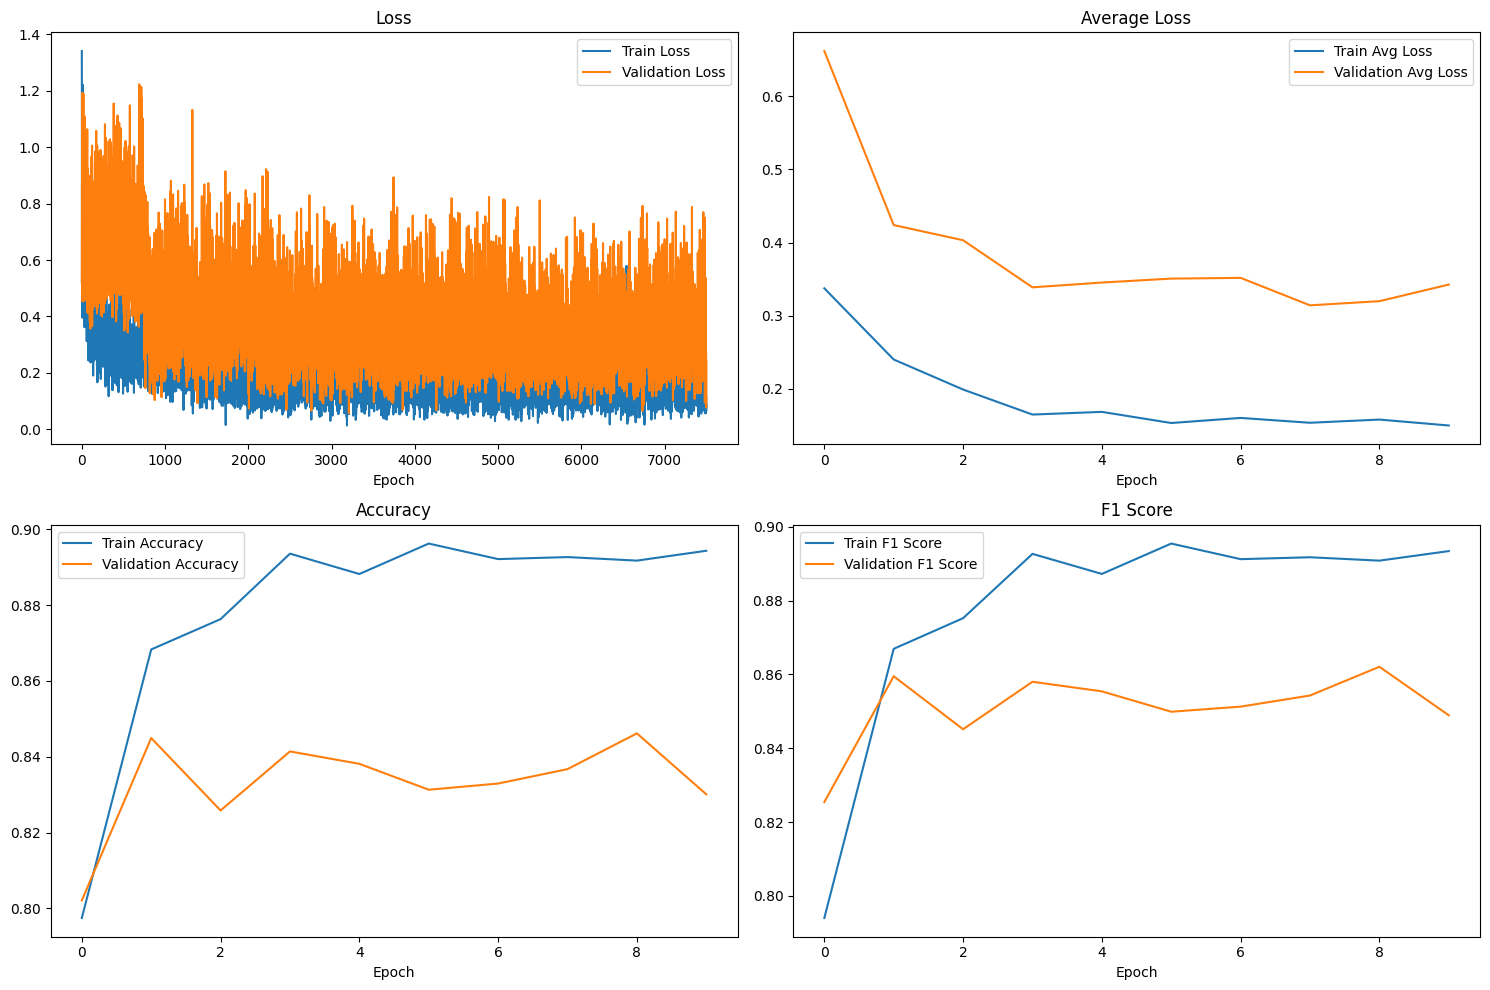

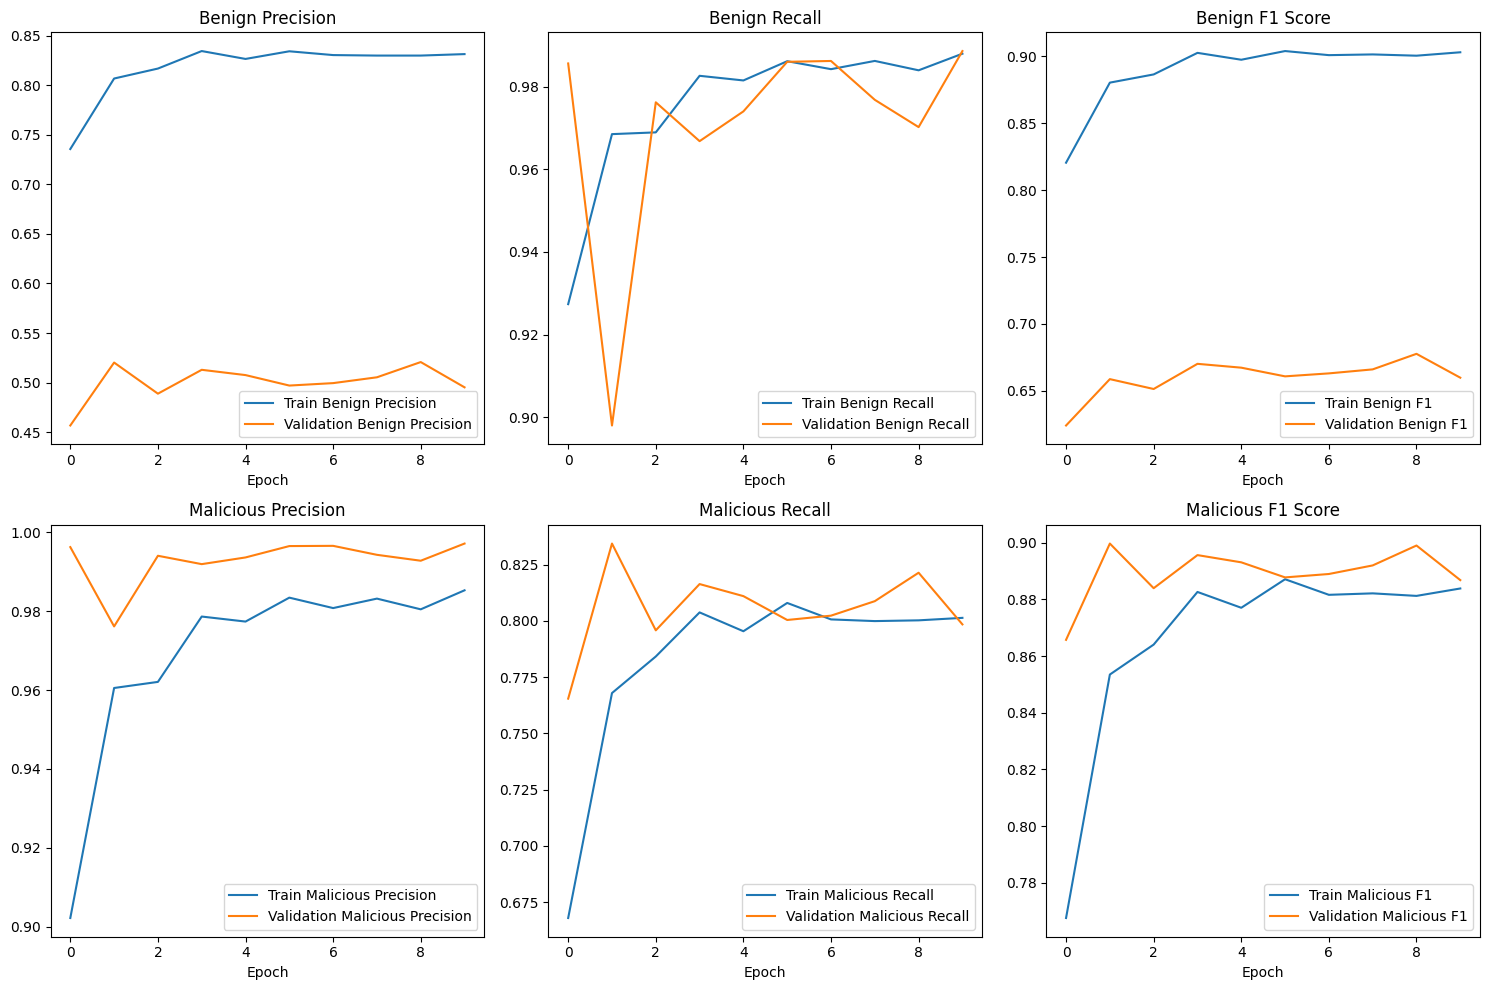

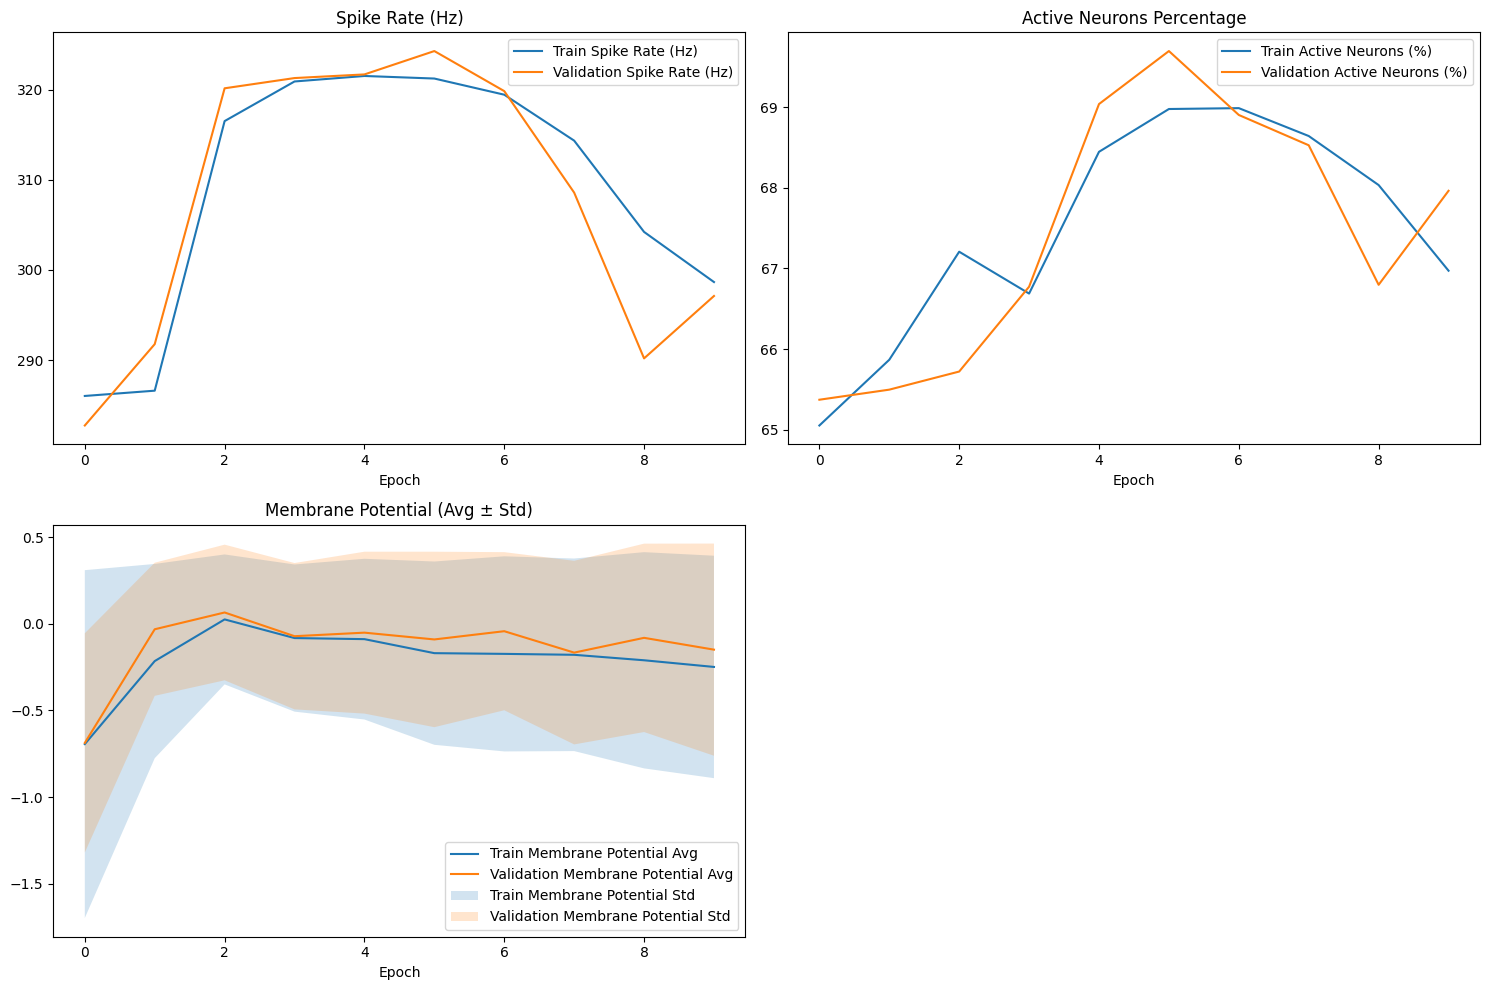

In [38]:
plot_metrics_snn(basic_snn_history["metrics"])

In [39]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

In [ ]:
def visualize_model(model_class, dummy_input, filepath, with_buffers=True):
    # Instantiate the model and move to the same device as dummy_input
    device = dummy_input.device
    model = model_class().to(device)
    
    # Set the model to evaluation mode
    model.eval()

    # Forward pass to generate the computation graph
    output = model(dummy_input)
    
    # Collect both named parameters and buffers for node names
    params = dict(model.named_parameters())
    if with_buffers:
        params.update(dict(model.named_buffers()))
    
    # Generate the visualization graph
    dot = make_dot(output, params=params)
    
    # Save the graph to the specified filepath
    dot.render(filename=filepath, cleanup=True, format='png')

In [53]:
BASE_DIR = "../../reports/figures"

from src.models import BinaryCNN, BinaryAbstractionCNN, BasicSNN, SNNClassifier

In [64]:
visualize_model(BasicSNN, torch.rand(1,1,32,32), f"{BASE_DIR}/basic_snn")